# Problem Definition 

##### The online refrigerator market has a wide variety of products with different brands, capacities, prices, ratings, and discounts.

##### Customers often find it difficult to compare refrigerators and choose the best option.
##### This project uses web scraping and Exploratory Data Analysis (EDA) to collect refrigerator data from Flipkart and analyze market trends, pricing strategies, and customer preferences.

# Business Problem Statement

##### Retailers and e-commerce platforms need to understand:
+ Which refrigerator brands are most popular
+ What price range attracts maximum customers
+ How discounts affect customer ratings
+ Which refrigerator capacities are in high demand
+ Market competition among brands

##### Without proper analysis, businesses may face poor pricing decisions and lower sales.

This project helps analyze refrigerator market data for better business decision-making.

# Project Objectives

##### The objectives of this project are:

+ To scrape refrigerator product data from Flipkart using Python and Selenium
+ To collect details such as:
+ Brand
+ Capacity
+ Number of doors
+ Price
+ Original Price
+ Discount
+ Ratings
+ To clean and preprocess the collected data
+ To perform Exploratory Data Analysis (EDA)
+ To compare refrigerator brands based on price and ratings
+ To identify customer buying trends
+ To visualize insights using charts and graphs

In [33]:
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import matplotlib.pyplot as plt
import seaborn
import re
import warnings
warnings.filterwarnings('ignore')

In [34]:
options=Options()
options.add_argument('--start-maximized')

service=Service(ChromeDriverManager().install())

In [35]:
driver=webdriver.Chrome(service=service,options=options)

In [36]:
url='https://www.flipkart.com/'

In [37]:
driver.get(url)

In [38]:
search_box = driver.find_element(By.XPATH,'//*[@id="container"]/div/div[1]/div/div/div/div/div/div/div/div/div/div[1]/div/div/div[2]/div/div/div/div/div/header/div[1]/div[1]/form/div/div/input')
search_box.send_keys('Refrigerators')
#search_box.click()
search_box.send_keys(Keys.RETURN)

In [39]:
a = driver.find_elements(By.CLASS_NAME, "RG5Slk")[0].text
a

'MarQ by Flipkart 92 L Direct Cool Single Door 1 Star Refrigerator'

In [40]:
Brand = []
Capacity = []
Door = []

for tag in driver.find_elements(By.CLASS_NAME, "RG5Slk"):
    text = tag.text

    Brand.append(text.split()[0])
    Capacity.append(re.search(r'(\d+\s*L)', text).group(1))
    Door.append(re.search(r'(Single Door|Double Door)', text).group(1))

print(Brand)
print(Capacity)
print(Door)

['MarQ', 'Blue', 'Haier', 'realme', 'Haier', 'Haier', 'Samsung', 'MarQ', 'Voltas', 'Whirlpool', 'MarQ', 'MarQ', 'Whirlpool', 'MarQ', 'MarQ', 'Haier', 'realme', 'MarQ', 'IFB', 'MarQ', 'MarQ', 'realme', 'Haier', 'Samsung']
['92 L', '45 L', '190 L', '84 L', '165 L', '190 L', '215 L', '183 L', '183 L', '192 L', '183 L', '183 L', '184 L', '183 L', '183 L', '190 L', '233 L', '183 L', '187 L', '183 L', '183 L', '233 L', '190 L', '189 L']
['Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Double Door', 'Single Door', 'Single Door', 'Single Door', 'Single Door', 'Double Door', 'Single Door', 'Single Door']


In [41]:
price=[]

for tag in driver.find_elements(By.CSS_SELECTOR,".hZ3P6w.DeU9vF"):  
    text=tag.text                                                   
    a=re.findall('₹(.+)',text)
    price.extend(a)
print(price)

['8,990', '9,990', '13,090', '9,490', '11,790', '14,090', '19,490', '11,490', '13,390', '17,040', '11,490', '10,990', '12,990', '11,990', '11,990', '13,890', '19,490', '11,990', '16,990', '11,490', '11,490', '20,490', '15,390', '17,790']


In [42]:
orginal_price=[]

for tag in driver.find_elements(By.CSS_SELECTOR,'.kRYCnD.gxR4EY'):
    text=tag.text
    a=re.findall('₹(.+)',text)
    orginal_price.extend(a)
print(orginal_price)

['14,990', '11,990', '18,990', '15,990', '16,590', '21,990', '30,999', '20,990', '27,990', '20,350', '20,990', '19,990', '15,800', '23,990', '23,990', '20,090', '34,990', '23,990', '23,990', '22,990', '22,990', '36,990', '24,390', '23,999']


In [43]:
Rating=[]

for tag in  driver.find_elements(By.CLASS_NAME,"MKiFS6"):
    text=tag.text
    Rating.append(text)
print(Rating)

['4.2', '4.2', '4.3', '4.3', '4.2', '4.4', '4.5', '4.2', '4.4', '4.4', '4.2', '4.2', '4.3', '4.2', '4.2', '4.3', '4.2', '4.2', '4.4', '4.2', '4.2', '4.2', '4.4', '4.5', '4.3', '5', '5', '4.2', '4', '5', '4.4', '5', '3', '4.3', '4', '5', '4.2', '4', '3']


In [47]:
Rating = Rating[:24]

print(len(Rating))

24


In [44]:
Discount = []

for tag in driver.find_elements(By.CLASS_NAME, "HQe8jr"):
    a = tag.text
    b = a.replace("OFF", "").replace("off", "").replace("%", "").strip()
    Discount.append(b)

print(Discount)

['40', '16', '31', '40', '28', '35', '37', '45', '52', '16', '45', '45', '17', '50', '50', '30', '44', '50', '29', '50', '50', '44', '36', '25', '40', '16', '29', '31', '28']


In [48]:
Discount = Discount[:24]

print(len(Discount))

24


In [49]:
len(Brand),len(Capacity),len(Door),len(price),len(orginal_price),len(Rating),len(Discount)

(24, 24, 24, 24, 24, 24, 24)

In [50]:
df = pd.DataFrame({'Brand':Brand,'Capacity':Capacity,'Door':Door,'Discount_Price':price,'Original_price':orginal_price,'rating':Rating,'Discount':Discount})
df

,Brand,Capacity,Door,Discount_Price,Original_price,rating,Discount
0,MarQ,92 L,Single Door,"8,990","14,990",4.2,40
1,Blue,45 L,Single Door,"9,990","11,990",4.2,16
2,Haier,190 L,Single Door,"13,090","18,990",4.3,31
3,realme,84 L,Single Door,"9,490","15,990",4.3,40
4,Haier,165 L,Single Door,"11,790","16,590",4.2,28
5,Haier,190 L,Single Door,"14,090","21,990",4.4,35
6,Samsung,215 L,Single Door,"19,490","30,999",4.5,37
7,MarQ,183 L,Single Door,"11,490","20,990",4.2,45
8,Voltas,183 L,Single Door,"13,390","27,990",4.4,52
9,Whirlpool,192 L,Single Door,"17,040","20,350",4.4,16


In [61]:
import re
import time

Brand=[]
Capacity=[]
Door=[]
price=[]
orginal_price=[]
Rating=[]
Discount=[]

for i in range(1,41):
    url=f'https://www.flipkart.com/search?q=Refrigerators&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}'
    
    driver.get(url)
    time.sleep(3)

    for tag in driver.find_elements(By.CLASS_NAME, "RG5Slk"):
        text = tag.text

        Brand.append(text.split()[0])

        cap = re.findall(r'(\d+\s*L)', text)
        Capacity.append(cap[0] if cap else "Not Found")

        door = re.findall(r'(Single Door|Double Door)', text)
        Door.append(door[0] if door else "Not Found")

    for tag in driver.find_elements(By.CSS_SELECTOR,".hZ3P6w.DeU9vF"):
        price.append(tag.text)

    for tag in driver.find_elements(By.CSS_SELECTOR,'.kRYCnD.gxR4EY'):
        orginal_price.append(tag.text)

    for tag in driver.find_elements(By.CLASS_NAME,"MKiFS6"):
        Rating.append(tag.text)

    for tag in driver.find_elements(By.CLASS_NAME,"HQe8jr"):
        Discount.append(tag.text)

    print(f'Page {i} scraped')

Page 1 scraped
Page 2 scraped
Page 3 scraped
Page 4 scraped
Page 5 scraped
Page 6 scraped
Page 7 scraped
Page 8 scraped
Page 9 scraped
Page 10 scraped
Page 11 scraped
Page 12 scraped
Page 13 scraped
Page 14 scraped
Page 15 scraped
Page 16 scraped
Page 17 scraped
Page 18 scraped
Page 19 scraped
Page 20 scraped
Page 21 scraped
Page 22 scraped
Page 23 scraped
Page 24 scraped
Page 25 scraped
Page 26 scraped
Page 27 scraped
Page 28 scraped
Page 29 scraped
Page 30 scraped
Page 31 scraped
Page 32 scraped
Page 33 scraped
Page 34 scraped
Page 35 scraped
Page 36 scraped
Page 37 scraped
Page 38 scraped
Page 39 scraped
Page 40 scraped


In [74]:
Brand=[]
Capacity=[]
Door=[]
price=[]
orginal_price=[]
Rating=[]
Discount=[]


for i in range(1,41):
    url=f'https://www.flipkart.com/search?q=Refrigerators&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}'
    driver.get(url)
    for tag in driver.find_elements(By.CLASS_NAME, "RG5Slk"):
        text = tag.text

    # Brand
        Brand.append(text.split()[0])

    # Capacity
        Capacity.append(re.findall(r'(\d+\s*L)', text))

    # Door
        Door.append(re.findall(r'(Single Door|Double Door)', text))


    for tag in driver.find_elements(By.CSS_SELECTOR,".hZ3P6w.DeU9vF"):  
        text=tag.text                                                   
        a=re.findall('₹(.+)',text)
        price.extend(a)
    for tag in driver.find_elements(By.CSS_SELECTOR,'.kRYCnD.gxR4EY'):
        text=tag.text
        a=re.findall('₹(.+)',text)
        orginal_price.extend(a)
    for tag in  driver.find_elements(By.CLASS_NAME,"MKiFS6"):
        text=tag.text
        Rating.append(text)
    for tag in driver.find_elements(By.CLASS_NAME, "HQe8jr"):
        a = tag.text
        b = a.replace("OFF", "").replace("off", "").replace("%", "").strip()
        Discount.append(b)


        
    print(f'Page {i} scraped')

Page 1 scraped
Page 2 scraped
Page 3 scraped
Page 4 scraped
Page 5 scraped
Page 6 scraped
Page 7 scraped
Page 8 scraped
Page 9 scraped
Page 10 scraped
Page 11 scraped
Page 12 scraped
Page 13 scraped
Page 14 scraped
Page 15 scraped
Page 16 scraped
Page 17 scraped
Page 18 scraped
Page 19 scraped
Page 20 scraped
Page 21 scraped
Page 22 scraped
Page 23 scraped
Page 24 scraped
Page 25 scraped
Page 26 scraped
Page 27 scraped
Page 28 scraped
Page 29 scraped
Page 30 scraped
Page 31 scraped
Page 32 scraped
Page 33 scraped
Page 34 scraped
Page 35 scraped
Page 36 scraped
Page 37 scraped
Page 38 scraped
Page 39 scraped
Page 40 scraped


In [75]:
data=list((Brand,Capacity,Door,price,orginal_price,Rating,Discount))

In [76]:
from itertools import zip_longest

data=list(zip_longest(Brand,Capacity,Door,price,orginal_price,Rating,Discount))
data

[('MarQ', ['183 L'], ['Single Door'], '11,490', '20,990', '4.2', '45'),
 ('MarQ', ['183 L'], ['Single Door'], '11,490', '20,990', '4.2', '45'),
 ('Haier', ['190 L'], ['Single Door'], '13,090', '18,990', '4.3', '31'),
 ('realme', ['84 L'], ['Single Door'], '9,490', '15,990', '4.3', '40'),
 ('Haier', ['165 L'], ['Single Door'], '11,790', '16,590', '4.2', '28'),
 ('Haier', ['190 L'], ['Single Door'], '14,090', '21,990', '4.4', '35'),
 ('Samsung', ['215 L'], ['Single Door'], '19,490', '30,999', '4.5', '37'),
 ('MarQ', ['183 L'], ['Single Door'], '10,990', '19,990', '4.2', '45'),
 ('Whirlpool', ['192 L'], ['Single Door'], '17,040', '20,350', '4.4', '16'),
 ('Voltas', ['183 L'], ['Single Door'], '13,390', '27,990', '4.4', '52'),
 ('MarQ', ['183 L'], ['Single Door'], '11,990', '23,990', '4.2', '50'),
 ('realme', ['233 L'], ['Double Door'], '19,490', '34,990', '4.2', '44'),
 ('Whirlpool', ['184 L'], ['Single Door'], '12,990', '15,800', '4.3', '17'),
 ('MarQ', ['183 L'], ['Single Door'], '11,99

In [84]:
data=list(zip_longest(Brand,Capacity,Door,price,orginal_price,Rating,Discount))
df=pd.DataFrame(data,columns=['Brand','Capacity','Door','price','orginal_price','Rating','Discount'])
df

,Brand,Capacity,Door,price,orginal_price,Rating,Discount
0,MarQ,[183 L],[Single Door],"11,490","20,990",4.2,45
1,MarQ,[183 L],[Single Door],"11,490","20,990",4.2,45
2,Haier,[190 L],[Single Door],"13,090","18,990",4.3,31
3,realme,[84 L],[Single Door],"9,490","15,990",4.3,40
4,Haier,[165 L],[Single Door],"11,790","16,590",4.2,28
...,...,...,...,...,...,...,...
1449,None,None,None,None,None,5,None
1450,None,None,None,None,None,4,None
1451,None,None,None,None,None,4.2,None
1452,None,None,None,None,None,4,None


In [85]:
df.to_csv('refrigerator_datascraped.csv',index=False) 

In [86]:
df=pd.read_csv(r'refrigerator_datascraped.csv')
df

,Brand,Capacity,Door,price,orginal_price,Rating,Discount
0,MarQ,['183 L'],['Single Door'],"11,490","20,990",4.2,45.0
1,MarQ,['183 L'],['Single Door'],"11,490","20,990",4.2,45.0
2,Haier,['190 L'],['Single Door'],"13,090","18,990",4.3,31.0
3,realme,['84 L'],['Single Door'],"9,490","15,990",4.3,40.0
4,Haier,['165 L'],['Single Door'],"11,790","16,590",4.2,28.0
...,...,...,...,...,...,...,...
1449,NaN,NaN,NaN,NaN,NaN,5.0,NaN
1450,NaN,NaN,NaN,NaN,NaN,4.0,NaN
1451,NaN,NaN,NaN,NaN,NaN,4.2,NaN
1452,NaN,NaN,NaN,NaN,NaN,4.0,NaN


In [88]:
df.shape

(1454, 7)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          936 non-null    object 
 1   Capacity       936 non-null    object 
 2   Door           936 non-null    object 
 3   price          933 non-null    object 
 4   orginal_price  923 non-null    object 
 5   Rating         1454 non-null   float64
 6   Discount       1115 non-null   float64
dtypes: float64(2), object(5)
memory usage: 79.6+ KB


In [90]:
df.describe()

,Rating,Discount
count,1454.000000,1115.000000
mean,4.213755,33.305830
std,0.625147,13.800799
min,1.000000,1.000000
25%,4.200000,22.000000
50%,4.200000,34.000000
75%,4.400000,45.000000
max,5.000000,56.000000


In [91]:
df.isnull().sum()

Brand            518
Capacity         518
Door             518
price            521
orginal_price    531
Rating             0
Discount         339
dtype: int64

In [92]:
df=df.dropna(subset='Brand')
df.isnull().sum()

Brand             0
Capacity          0
Door              0
price             3
orginal_price    13
Rating            0
Discount          0
dtype: int64

In [94]:
df[df[['price','orginal_price']].isnull().any(axis=1)]

,Brand,Capacity,Door,price,orginal_price,Rating,Discount
923,MarQ,['183 L'],['Single Door'],"11,490",NaN,4.1,50.0
924,Godrej,['180 L'],['Single Door'],"20,490",NaN,4.4,2.0
925,Samsung,['396 L'],['Double Door'],"44,690",NaN,4.2,32.0
926,MarQ,['183 L'],['Single Door'],"9,999",NaN,4.2,16.0
927,realme,['233 L'],['Double Door'],"16,500",NaN,4.2,14.0
928,Whirlpool,['431 L'],['Double Door'],"15,490",NaN,5.0,44.0
929,Sharp,['50 L'],['Single Door'],"14,490",NaN,4.4,50.0
930,Whirlpool,['184 L'],['Single Door'],"41,990",NaN,4.3,11.0
931,Lloyd,['178 L'],['Single Door'],"18,260",NaN,4.2,6.0
932,realme,['180 L'],['Single Door'],"16,390",NaN,4.2,50.0


In [95]:
df['orginal_price'] = df['orginal_price'].str.replace(',', '')

df['orginal_price'] = pd.to_numeric(df['orginal_price'], errors='coerce')

In [96]:
df['orginal_price'] = df['orginal_price'].fillna(df['orginal_price'].mean())

In [97]:
df['price'] = df['price'].str.replace(',', '')

df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [98]:
df['price'] = df['price'].fillna(df['price'].mean())

In [99]:
df.isnull().sum()

Brand            0
Capacity         0
Door             0
price            0
orginal_price    0
Rating           0
Discount         0
dtype: int64

In [100]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,936.0,22987.857449,17773.111474,4390.0,11990.0,18190.0,25590.0,199990.0
orginal_price,936.0,35152.983749,26696.650967,9999.0,21090.0,25825.0,36922.5,349990.0
Rating,936.0,4.201709,0.645956,1.0,4.2,4.2,4.4,5.0
Discount,936.0,33.613248,13.654875,1.0,22.0,34.0,45.0,56.0


In [101]:
import seaborn as sns

# Univariate Analysis
(Analyze one column)

<Axes: xlabel='Brand'>

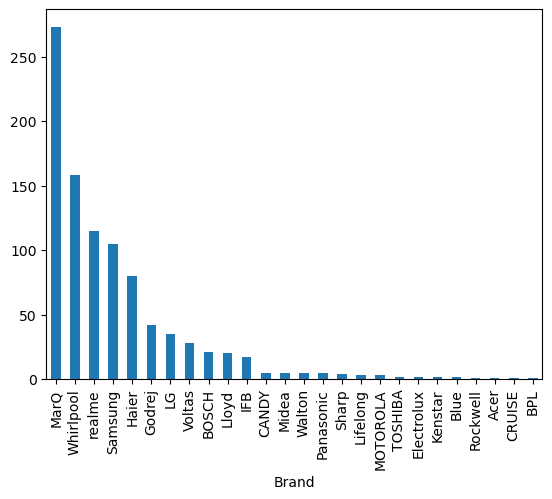

In [127]:
df['Brand'].value_counts().plot(kind='bar') # Brard count

<Axes: ylabel='count'>

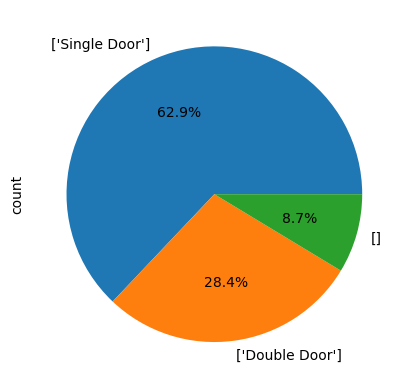

In [129]:
df['Door'].value_counts().plot(kind='pie', autopct='%1.1f%%') #Door type distribution

<Axes: ylabel='Frequency'>

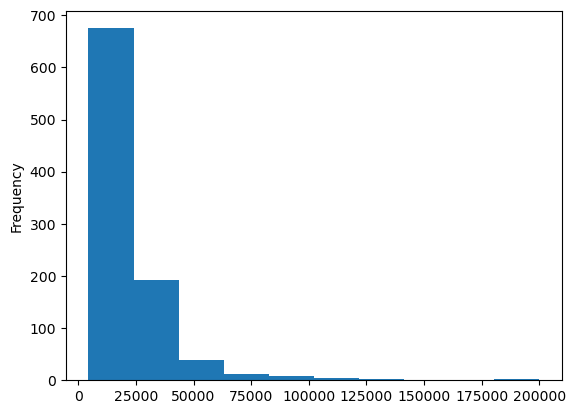

In [131]:
df['price'].plot(kind='hist') #Price distribution

# Bivariate Analysis
(Relationship between 2 columns)

<Axes: xlabel='Brand'>

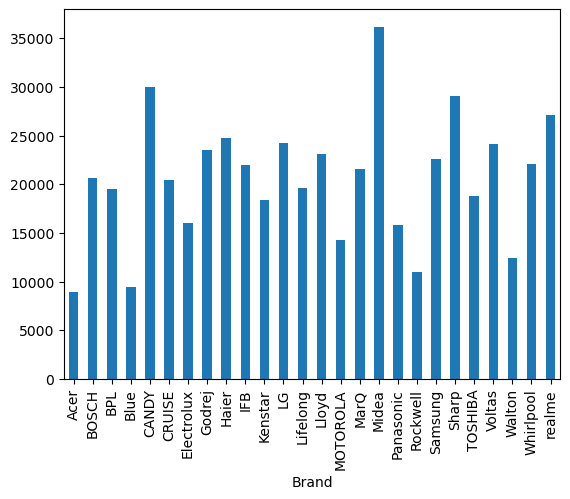

In [134]:
df.groupby('Brand')['price'].mean().plot(kind='bar') #Brand vs Price

<Axes: xlabel='Door'>

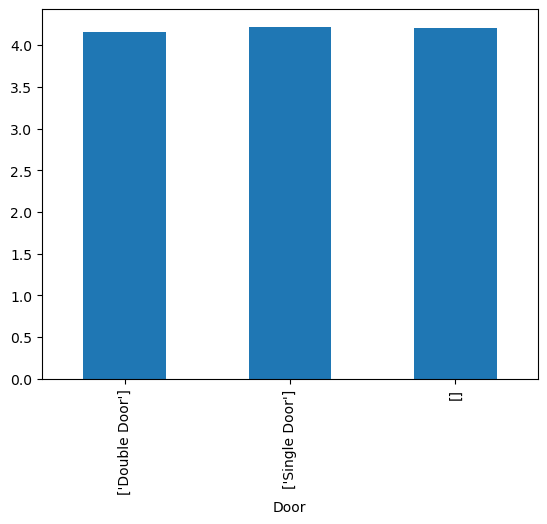

In [135]:
df.groupby('Door')['Rating'].mean().plot(kind='bar') #Door vs Rating

# Multivariate Analysis
(Relationship between 3+ columns)

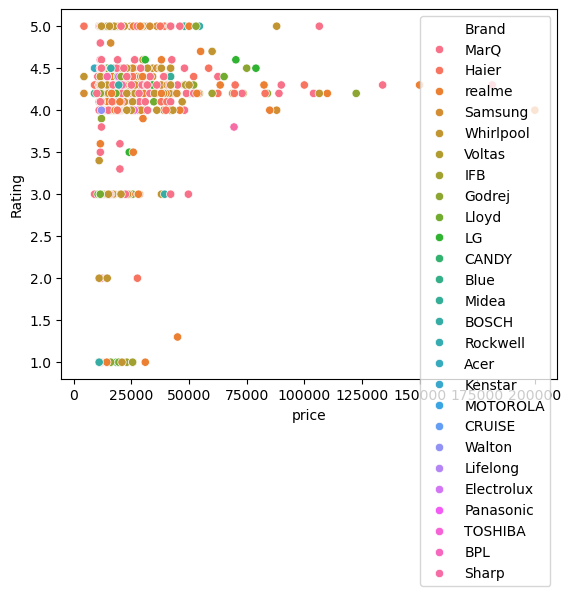

In [137]:
sns.scatterplot(data=df, x='price', y='Rating', hue='Brand')
plt.show() #Brand vs Price vs Rating

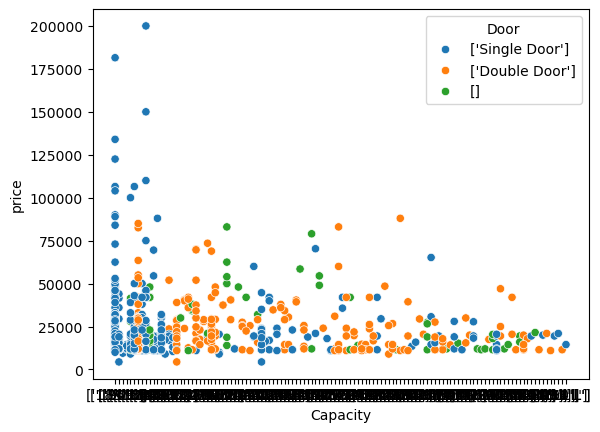

In [139]:
sns.scatterplot(data=df, x='Capacity', y='price', hue='Door')
plt.show() #Capacity vs Price vs Door

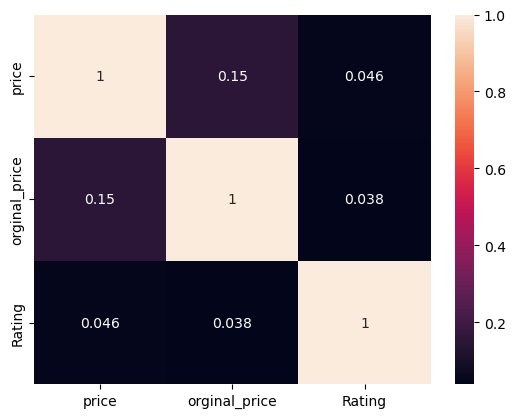

In [140]:
sns.heatmap(df[["price","orginal_price","Rating"]].corr(),annot=True)
plt.show() #price vs orginal_price,

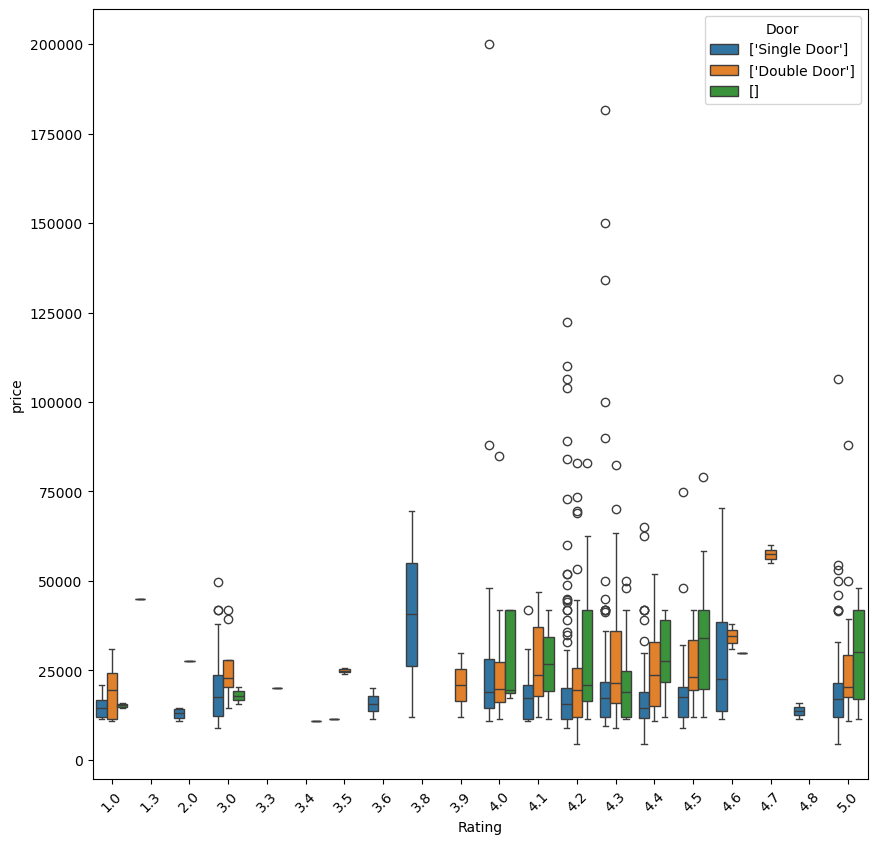

In [146]:
plt.figure(figsize=(10,10))

sns.boxplot(x="Rating",y="price",hue="Door",data=df)
plt.xticks(rotation=45)
plt.show()

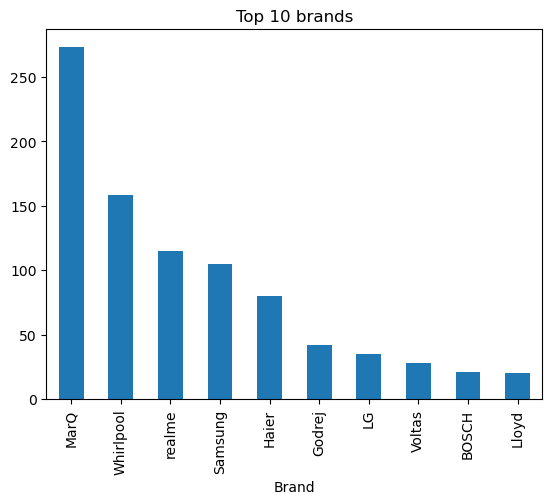

In [148]:
df['Brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 brands')
plt.show()

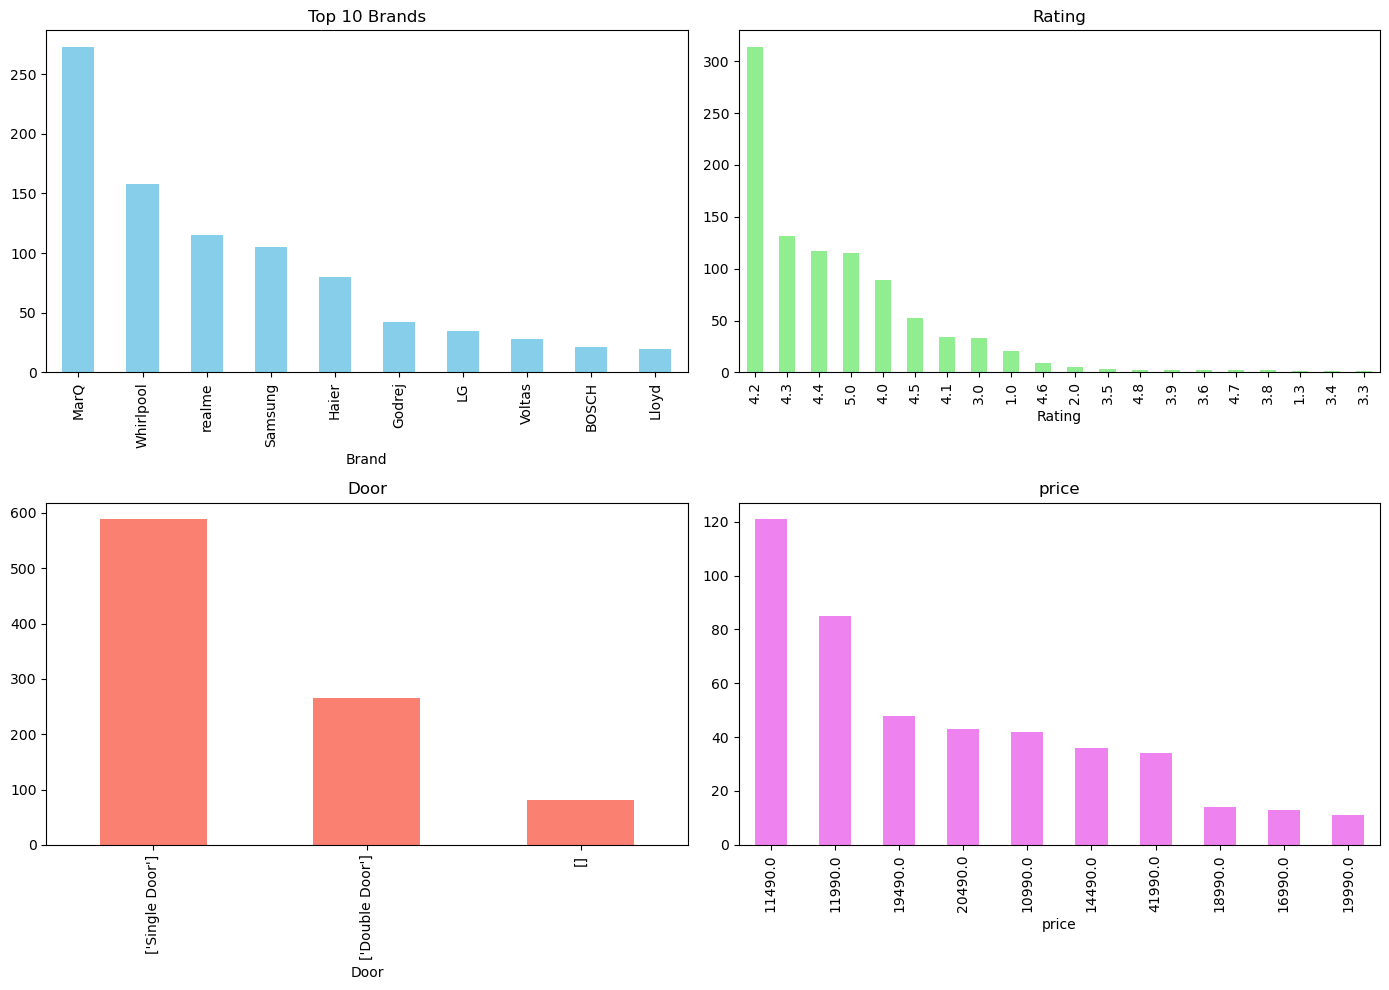

In [153]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Brand'].value_counts().head(10).plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 10 Brands')

df['Rating'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Rating')


df['Door'].value_counts().plot(kind='bar', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Door')

df['price'].value_counts().head(10).plot(kind='bar', ax=axes[1,1], color='violet')
axes[1,1].set_title('price')

plt.tight_layout()
plt.show()

# Hypothesis Testing

## Hypothesis 1 (brand vs Price)

In [155]:
from scipy.stats import ttest_ind

samsung = df[df["Brand"]=="Samsung"]["price"].dropna()
lg = df[df["Brand"]=="LG"]["price"].dropna()

t_stat, p_value = ttest_ind(samsung, lg)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.6299749365719765
P-Value: 0.5297526863036244


In [170]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


# Hypothesis 2 (Rating vs price)

In [176]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['Rating'], df['price'])

print("Correlation:", corr)
print("p-value:", p)

Correlation: 0.04648339759013668
p-value: 0.15532074814020358


In [177]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


# Hypothesis 3 (Rating vs price)

In [186]:
from scipy.stats import ttest_ind

# Convert Capacity to numeric first
df['Capacity'] = df['Capacity'].astype(str).str.extract(r'(\d+)').astype(float)

samsung = df[df["Brand"] == "Samsung"]["Capacity"].dropna()
lg      = df[df["Brand"] == "LG"]["Capacity"].dropna()

t_stat, p_value = ttest_ind(samsung, lg)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 1.256658277288081
P-Value: 0.21100036511656708


# Conclusions & Insights

# Pricing Analysis
##### Most refrigerators fall under the mid-range price segment
##### Premium refrigerators are fewer but offer advanced features
# Brand Analysis
##### Certain brands dominate the refrigerator market
##### Popular brands often maintain stable ratings
# Discount Analysis
##### Products with discounts attract more customer attention
##### Moderate discounts are common across top-selling products
# Capacity Trends
##### Medium-capacity refrigerators are more commonly listed
##### Family-sized refrigerators are priced higher
# Customer Preferences

##### Customers mostly prefer refrigerators with: